# Lab 01: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python in Jupyter Notebook

**Name:** Shrisan kapali  
**Course:** MSCS 634 B01

**Assignment:** Lab 01 - Data Visualization, Data Preprocessing, and Statistical Analysis Using Python in Jupyter Notebook

In [1]:
# Basic imports to get the dataset loaded
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import matplotlib.ticker as ticker
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")

## Step 1: Data Collection

The **2025 Iowa Liquor Sales** dataset was extracted from **Data.gov**.

* **Dataset:** Iowa Liquor Sales (2025)
* **Source:** https://catalog.data.gov/dataset/iowa-liquor-sales-2025?from_hint=eyJxIjoiaW93YSBsaXF1b3Igc2FsZXMifQ%3D%3D
* **Data File:** `IOWA_Liquor_Sales.csv`
* **Number of Records:** **769,495**
* **Description:** The dataset contains liquor sales records from stores located across multiple locations in Iowa.


In [2]:
# Read the csv file
df = pd.read_csv("IOWA_LIQUOR_SALES.csv", low_memory=False)
print("Full Meta Data:", df.shape)

# Displaying the first 5 data using head
df.head()

Full Meta Data: (769495, 21)


,invoice_id,ordered_on,store_no,store_name,store_address,store_city,store_zip_code,county_fips_code,county_name,category_code,...,vendor_number,vendor_name,item_no,im_desc,pack,bottle_volume_ml,sales_bottles,sales_dollars,sales_liters,sales_gallons
0,INV-78192100069,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036.0,19015.0,BOONE,1022200,...,395,PROXIMO,87510,1800 SILVER,12,750,3,74.25,2.25,0.59
1,INV-78192100072,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036.0,19015.0,BOONE,1022200,...,65,JIM BEAM BRANDS,88540,HORNITOS LIME SHOT,12,750,12,270.00,9.00,2.37
2,INV-78192100070,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036.0,19015.0,BOONE,1022200,...,421,SAZERAC COMPANY INC,88036,MARGARITAVILLE SILVER TEQUILA,12,750,3,41.85,2.25,0.59
3,INV-78192100071,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036.0,19015.0,BOONE,1022200,...,460,SHAW-ROSS INTERNATIONAL,88172,SANTO TEQUILA REPOSADO,6,750,2,82.50,1.50,0.39
4,INV-78192100061,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036.0,19015.0,BOONE,1081300,...,65,JIM BEAM BRANDS,85526,DEKUYPER BLUE CURACAO,12,750,12,94.56,9.00,2.37


## Step 2: Data Visualization


## Scatter Plot Showing the Relationship Between Sales Amount and Gallons Sold

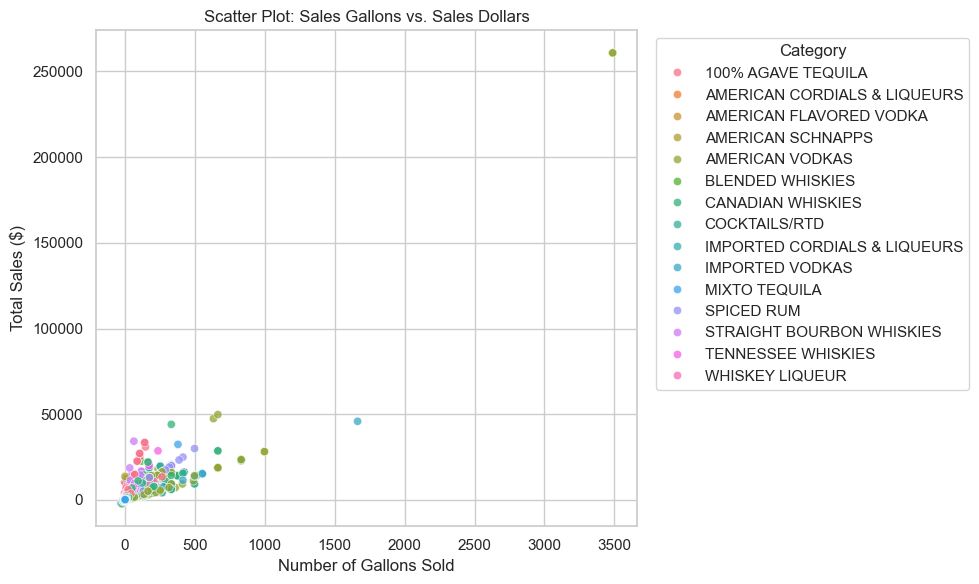

<Figure size 640x480 with 0 Axes>

In [3]:
# ---------------------------------------------------------
# SCATTER PLOT showing top 15 records
# ---------------------------------------------------------

# Converting the "ordered_on" column date record which is in format "MM/DD/YYYY" to an actual date object
df['ordered_on'] = pd.to_datetime(df['ordered_on'])

# Getting top 15 records
top_15_categories = df["category_name"].value_counts().head(15).index
df_top_cat = df[df["category_name"].isin(top_15_categories)]

# Set a nice theme for all our plots
sns.set_theme(style="whitegrid")

# Plotting the diagram
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_top_cat, x='sales_gallons', y='sales_dollars',hue="category_name", alpha=0.75, color='blue')
plt.title('Scatter Plot: Sales Gallons vs. Sales Dollars')
plt.xlabel('Number of Gallons Sold')
plt.ylabel('Total Sales ($)')
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig('Scatter_Plot_Sales_Gallons_VS_Sales_Dollars.png', dpi=300, bbox_inches='tight')
plt.show()

plt.clf()

**Insight:** There is a positive correlation between the number of gallons sold and total sales dollars, which is to be expected. However, the slope varies, reflecting different price points per gallon across categories.The vast majority of sales transactions cluster densely at the lower end of both gallons sold (under 500) and sales dollars (under $50,000).There is a massive outlier for AMERICAN SCHNAPPS, showing a single data point with approximately 3,500 gallons sold and over $250,000 in sales, far exceeding typical transaction sizes.

## Box Plot Sales distribution by category

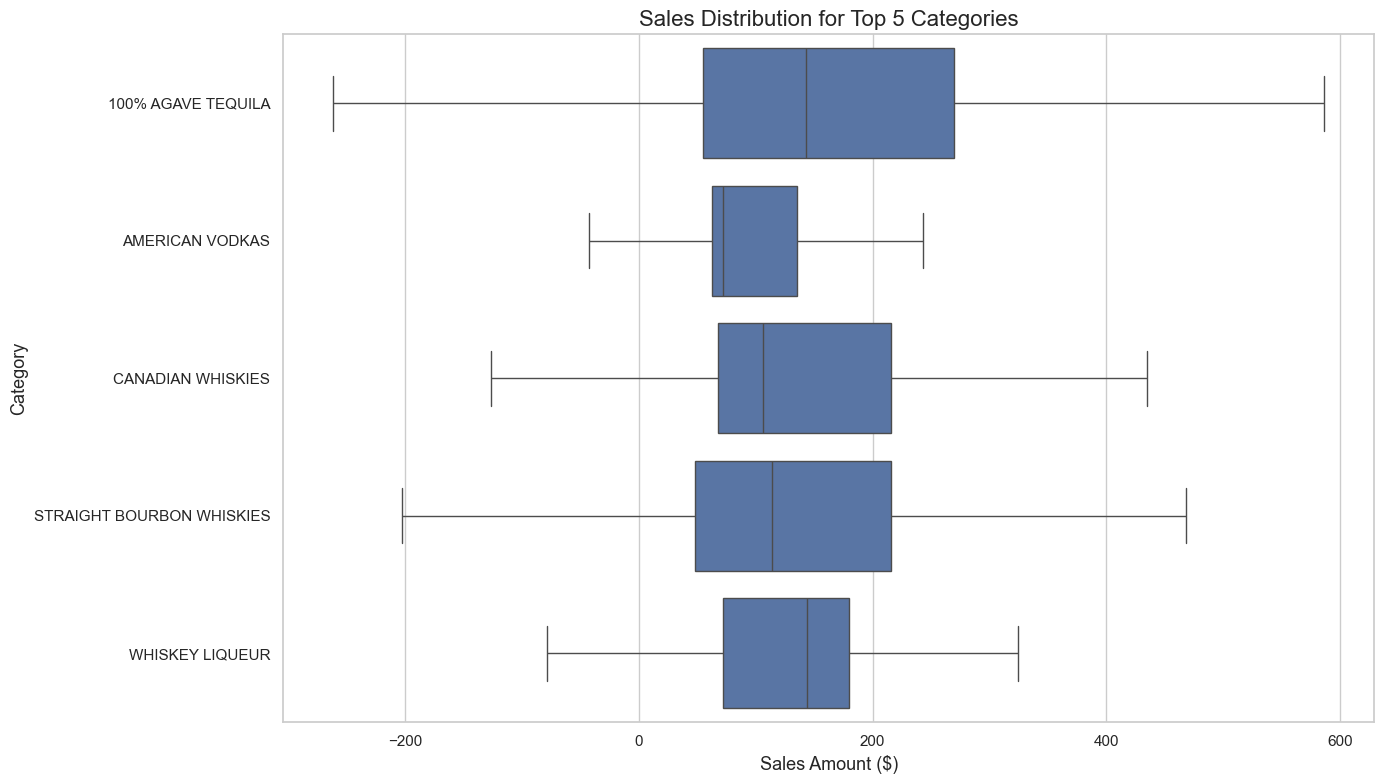

<Figure size 640x480 with 0 Axes>

In [4]:
# ---------------------------------------------------------
# Box PLOT showing top 5 sales category
# ---------------------------------------------------------
plt.figure(figsize=(14, 8))

top_5_cats = df['category_name'].value_counts().head(5).index
df_top_5 = df[df['category_name'].isin(top_5_cats)]

# for visualization we are hiding extreme outliers
sns.boxplot(data=df_top_5, x='sales_dollars', y='category_name', showfliers=False)

plt.title('Sales Distribution for Top 5 Categories', fontsize=16)
plt.xlabel('Sales Amount ($)', fontsize=13)
plt.ylabel('Category', fontsize=13)
plt.tick_params(axis='both', labelsize=11)

plt.tight_layout()

plt.savefig('Box_Plot_Top_5_Sales_Categories.png', dpi=300, bbox_inches='tight')
plt.show()

plt.clf()

**Insight:** Despite AMERICAN VODKAS selling the most bottles overall, its median sales amount per transaction is the lowest among the top 5 categories, and it has a very narrow distribution. 100% AGAVE TEQUILA shows the highest median sales amount and the widest interquartile range, indicating that while it may not sell the highest volume of bottles, individual sales transactions tend to be much higher in dollar value.

## Bar Chart of Top 10 bottles sold by Category

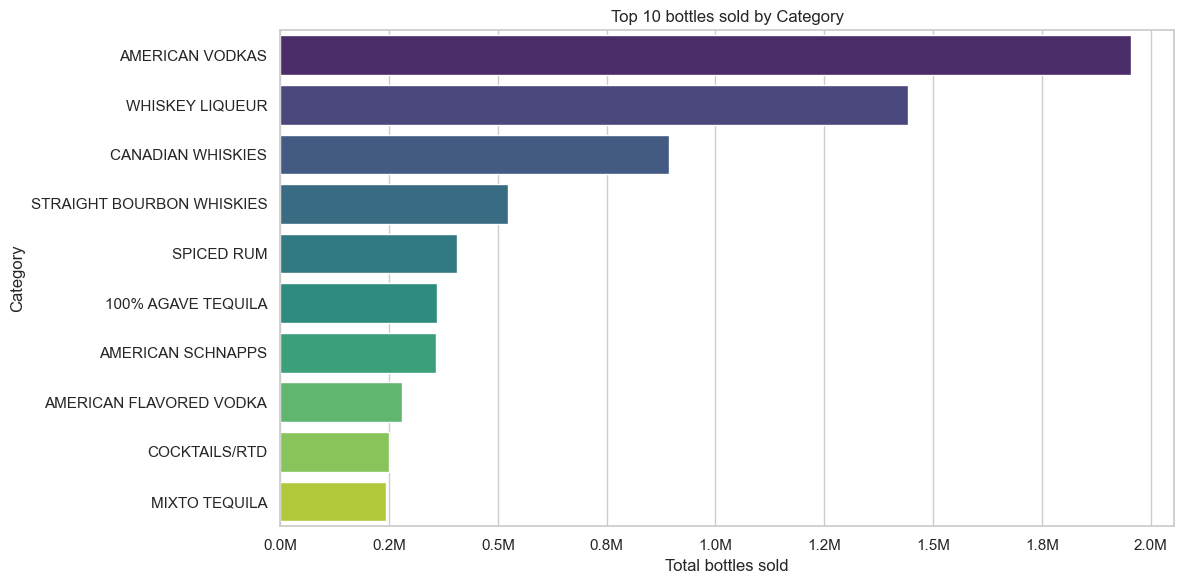

<Figure size 640x480 with 0 Axes>

In [5]:
# ---------------------------------------------------------
# Bar chart of top 10 liquor categoies by total bottles sold
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

#Grouping and extracting 10 most sold category
category_totals = df.groupby("category_name")["sales_bottles"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=category_totals.values, y=category_totals.index, hue=category_totals.index, palette="viridis", legend=False)
plt.title("Top 10 bottles sold by Category")
plt.xlabel("Total bottles sold")
plt.ylabel("Category")

# Format x-axis labels
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.tight_layout()
plt.savefig('Bar_Chart_Top_10_Bottles_Category_Sold.png', dpi=300, bbox_inches='tight')
plt.show()

plt.clf()

**Insight:** AMERICAN VODKAS lead the market significantly in sheer volume, nearing 2.0 million total bottles sold.WHISKEY LIQUEUR and CANADIAN WHISKIES follow in second and third place, with approximately 1.45 million and 900,000 bottles sold, respectively. Categories like MIXTO TEQUILA and COCKTAILS/RTD are at the bottom of the top 10, each selling just around 200,000 bottles.

## Line Plot of daily sales over time

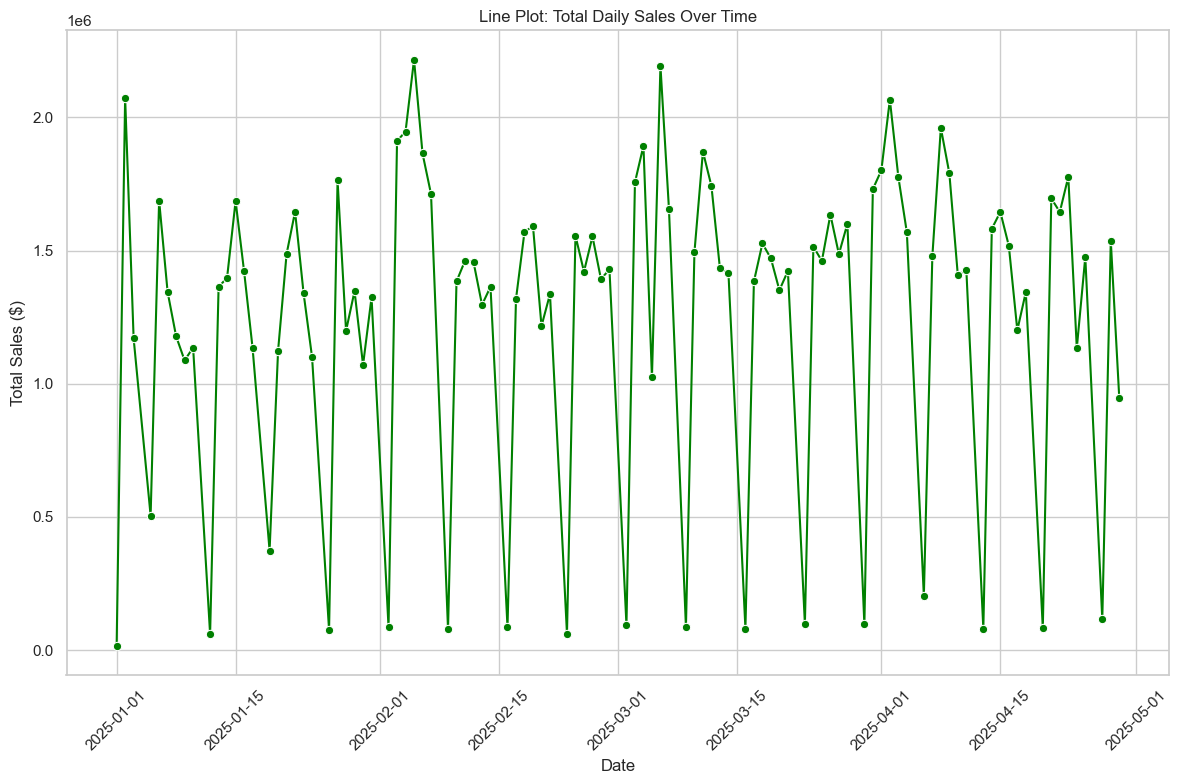

<Figure size 640x480 with 0 Axes>

In [6]:
# ---------------------------------------------------------
# Line plot of daily sales respective to time
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))
daily_sales = df.groupby('ordered_on')['sales_dollars'].sum().reset_index()
sns.lineplot(data=daily_sales, x='ordered_on', y='sales_dollars', marker='o', color='green')
plt.title('Line Plot: Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Line_Plot_Daily_Sales_Over_Time.png', dpi=300, bbox_inches='tight')
plt.show()

plt.clf()

**Insight:** Total daily sales exhibit a highly cyclical, likely weekly, pattern between January 2025 and May 2025 .Sales consistently peak between $1.5 million and $2.2 million before sharply dropping to near zero on a regular interval (likely corresponding to weekends, closed store days, or specific reporting gaps).

## Step 3: Data Preprocessing

## 1. Handling Missing Values

Finding the missing columns where the value is null or is not a number 

In [7]:
# Create a copy of the record
df_clean = df.copy()

# 1. HANDLING MISSING VALUES
before_counts = df_clean.isna().sum()
missing_before = df_clean.isna().sum().to_frame(name="Missing Count Before")
# Only display columns that actually have missing values
display(missing_before[missing_before["Missing Count Before"] > 0])


,Missing Count Before
store_address,278
store_city,278
store_zip_code,278
county_fips_code,278
county_name,278


The sample contains real-world missing values in `category_name`, `category_code`, `county_name`, `county_fips_code`, `store_address`, `store_city`, and `store_zip_code` -- these come directly from gaps in the source data, not synthetic injection.

## Now handling Missing values
If the value is a numeric, we fill with the median, if text replacing with "Unknown"

In [8]:
# Find the missing columns
cols_with_missing = df_clean.columns[df_clean.isna().any()].tolist()
for col in cols_with_missing:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    else:
        df_clean[col] = df_clean[col].fillna('Unknown')
        
# Missing counts AFTER
after_counts = df_clean.isna().sum()

# Creating a side by side comparision
missing_comparison = pd.DataFrame({
    'Column Name': before_counts.index,
    'Missing Before': before_counts.values,
    'Missing After': after_counts.values
})

# Displaying the comparision
missing_comparison = missing_comparison[missing_comparison['Missing Before'] > 0]
display(missing_comparison.reset_index(drop=True))

,Column Name,Missing Before,Missing After
0,store_address,278,0
1,store_city,278,0
2,store_zip_code,278,0
3,county_fips_code,278,0
4,county_name,278,0


Missing values were handled with mode imputation for categorical fields (`category_name`, `store_zip_code`), a constant `"Unknown"` fill for `county_name`/`store_address`, and forward/backward fill for `store_city`. The largely-redundant `category_code` and `county_fips_code` columns (numeric codes for fields already captured by name) were dropped rather than imputed.

### 2. Outlier Detection and Removal based on sales dollar amount
We calculate the IQR and calculate the upper and lower bounds

In [9]:
Q1 = df_clean["sales_dollars"].quantile(0.25)
Q3 = df_clean["sales_dollars"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["sales_dollars"] < lower_bound) | (df_clean["sales_dollars"] > upper_bound)]
df_no_outliers = df_clean[(df_clean['sales_dollars'] >= lower_bound) & (df_clean['sales_dollars'] <= upper_bound)].copy()

outlier_stats = pd.DataFrame({
    "Metric": ["Q1", "Q3", "IQR", "Lower Bound", "Upper Bound", "Initial Rows", "Outliers Detected", "Clean Rows"],
    "Value": [Q1, Q3, IQR, lower_bound, upper_bound, len(df), len(outliers), len(df_no_outliers)]
})
display(outlier_stats)
outliers[["invoice_id", "category_name", "sales_bottles", "sales_dollars"]].head()

,Metric,Value
0,Q1,51.750
1,Q3,170.880
2,IQR,119.130
3,Lower Bound,-126.945
4,Upper Bound,349.575
5,Initial Rows,769495.000
6,Outliers Detected,46729.000
7,Clean Rows,722766.000


,invoice_id,category_name,sales_bottles,sales_dollars
63,INV-78192100012,TENNESSEE WHISKIES,12,599.04
64,INV-78192100011,TENNESSEE WHISKIES,12,364.92
73,INV-78191800006,100% AGAVE TEQUILA,12,513.00
107,INV-78192000029,IMPORTED CORDIALS & LIQUEURS,12,413.64
117,INV-78192000002,IRISH WHISKIES,6,359.82


The IQR rule is applied to `sales_dollars`. Rows flagged include both unusually large bulk sales and the negative-dollar return transactions -- both are legitimate reasons to treat a row as atypical for this analysis.

Removing outliers reduces the dataset size and sharpens the focus on typical, representative sales transactions.

### 3. Data Reduction

In [10]:
# Calculating the shape before reducing
print("Shape before outlier removal", df_no_outliers.shape)

# Now dropping unnecessary columns
df_reduced = df_no_outliers.copy()
before_reduction = df_reduced.shape

df_reduced = df_reduced.drop(columns=[
    "invoice_id", "item_no", "im_desc", "store_address", "store_zip_code", "vendor_number"
], errors='ignore')

df_sampled = df_reduced.sample(frac=0.5, random_state=42).reset_index(drop=True)
print("Shape after outlier removal", df_sampled.shape)

df_sampled.head()


Shape before outlier removal (722766, 21)
Shape after outlier removal (361383, 15)


,ordered_on,store_no,store_name,store_city,county_fips_code,county_name,category_code,category_name,vendor_name,pack,bottle_volume_ml,sales_bottles,sales_dollars,sales_liters,sales_gallons
0,2025-01-22,3866,TARGET STORE T-1170 / AMES,AMES,19169.0,STORY,1071000,COCKTAILS/RTD,PROXIMO,6,1750,6,99.36,10.50,2.77
1,2025-01-28,2544,HY-VEE FOOD STORE (1403) / MARSHALLTOWN,MARSHALLTOWN,19127.0,MARSHALL,1031200,AMERICAN FLAVORED VODKA,DIAGEO AMERICAS,12,50,1,6.92,0.05,0.01
2,2025-04-11,2649,HY-VEE #3 / DUBUQUE,DUBUQUE,19061.0,DUBUQUE,1051100,AMERICAN BRANDIES,LUXCO INC,12,1000,12,121.56,12.00,3.17
3,2025-03-28,3833,WAL-MART 3394 / ATLANTIC,ATLANTIC,19029.0,CASS,1031100,AMERICAN VODKAS,SAZERAC COMPANY INC,6,1750,6,62.28,10.50,2.77
4,2025-02-07,2618,HY-VEE DRUGSTORE #6 / CEDAR RAPIDS,CEDAR RAPIDS,19113.0,LINN,1012100,CANADIAN WHISKIES,DIAGEO AMERICAS,10,50,3,25.92,0.15,0.03


The dataset was reduced by dropping columns that are pure identifiers or redundant descriptive text (`invoice_id`, `item_no`, `im_desc`, `store_address`, `store_zip_code`, `vendor_number`), while keeping `category_name`, `vendor_name`, `store_no`, `store_name`, `store_city`, `county_name`, `pack`, `bottle_volume_ml`, and all the sales measures. Rows were then further reduced by sampling 50% of what remained after outlier removal.

### 4. Data Scaling and Discretization

In [11]:
df_scaled = df_sampled.copy()

# Using MinMax Scalar and applying to sales_dollas, and sales_liters
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_scaled[["sales_dollars", "sales_liters"]])
df_scaled[["sales_dollars_scaled", "sales_liters_scaled"]] = scaled_values

bins = [0, 0.33, 0.66, 1.0]
labels = ["Low", "Medium", "High"]
df_scaled["sale_category"] = pd.cut(df_scaled["sales_dollars_scaled"], bins=bins, labels=labels, include_lowest=True)

df_scaled[["sales_dollars", "sales_dollars_scaled", "sale_category"]].head(10)


,sales_dollars,sales_dollars_scaled,sale_category
0,99.36,0.474807,Medium
1,6.92,0.280254,Low
2,121.56,0.521530,Medium
3,62.28,0.396767,Medium
4,25.92,0.320242,Low
5,85.50,0.445637,Medium
6,286.44,0.868544,High
7,71.25,0.415646,Medium
8,151.08,0.583660,Medium
9,66.24,0.405102,Medium


Min-Max scaling was applied to `sales_dollars` and `sales_liters` to bring both onto a 0-1 range, and the scaled sale amount was discretized into Low/Medium/High categories.

## Step 4: Statistical Analysis

### 1. General Overview of Data

In [12]:
# General info of df_scaled
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361383 entries, 0 to 361382
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ordered_on            361383 non-null  datetime64[ns]
 1   store_no              361383 non-null  int64         
 2   store_name            361383 non-null  object        
 3   store_city            361383 non-null  object        
 4   county_fips_code      361383 non-null  float64       
 5   county_name           361383 non-null  object        
 6   category_code         361383 non-null  int64         
 7   category_name         361383 non-null  object        
 8   vendor_name           361383 non-null  object        
 9   pack                  361383 non-null  int64         
 10  bottle_volume_ml      361383 non-null  int64         
 11  sales_bottles         361383 non-null  int64         
 12  sales_dollars         361383 non-null  float64       
 13 

In [13]:
# Describing the df_scaled
df_scaled.describe()

,ordered_on,store_no,county_fips_code,category_code,pack,bottle_volume_ml,sales_bottles,sales_dollars,sales_liters,sales_gallons,sales_dollars_scaled,sales_liters_scaled
count,361383,361383.000000,361383.000000,3.613830e+05,361383.000000,361383.000000,361383.000000,361383.000000,361383.000000,361383.000000,361383.000000,361383.000000
mean,2025-03-01 19:22:19.364607488,5097.471619,19112.923815,1.054500e+06,11.876170,764.665659,9.325226,108.711523,5.721950,1.505761,0.494489,0.228393
min,2025-01-01 00:00:00,2106.000000,19001.000000,1.011100e+06,1.000000,20.000000,-48.000000,-126.240000,-21.000000,-5.540000,0.000000,0.000000
25%,2025-01-31 00:00:00,2715.000000,19061.000000,1.012100e+06,6.000000,375.000000,2.000000,47.740000,1.200000,0.310000,0.366166,0.189744
50%,2025-03-03 00:00:00,4780.000000,19123.000000,1.031100e+06,12.000000,750.000000,6.000000,84.960000,4.500000,1.180000,0.444501,0.217949
75%,2025-04-01 00:00:00,5916.000000,19153.000000,1.071000e+06,12.000000,1000.000000,12.000000,155.960000,9.000000,2.370000,0.593930,0.256410
max,2025-04-29 00:00:00,10585.000000,19197.000000,1.901000e+06,48.000000,5250.000000,192.000000,348.900000,96.000000,25.360000,1.000000,1.000000
std,NaN,2377.624952,54.636871,9.719703e+04,8.713781,539.874085,12.750747,79.952010,5.274227,1.393734,0.168270,0.045079


### 2. Central Tendency Measures

In [14]:

numeric_cols = ["pack", "bottle_volume_ml", "sales_bottles", "sales_liters", "sales_dollars", "sales_gallons"]
central_tendency = pd.DataFrame({
    "Min": df_scaled[numeric_cols].min(),
    "Max": df_scaled[numeric_cols].max(),
    "Mean": round(df_scaled[numeric_cols].mean(),2),
    "Median": df_scaled[numeric_cols].median(),
    "Mode": df_scaled[numeric_cols].mode().iloc[0],
})
central_tendency

,Min,Max,Mean,Median,Mode
pack,1.00,48.00,11.88,12.00,12.00
bottle_volume_ml,20.00,5250.00,764.67,750.00,750.00
sales_bottles,-48.00,192.00,9.33,6.00,12.00
sales_liters,-21.00,96.00,5.72,4.50,9.00
sales_dollars,-126.24,348.90,108.71,84.96,72.00
sales_gallons,-5.54,25.36,1.51,1.18,2.37


### 3. Dispersion Measures

In [15]:
dispersion = pd.DataFrame({
    "Range": df_scaled[numeric_cols].max() - df_scaled[numeric_cols].min(),
    "Q1": df_scaled[numeric_cols].quantile(0.25),
    "Q3": df_scaled[numeric_cols].quantile(0.75),
    "IQR": df_scaled[numeric_cols].quantile(0.75) - df_scaled[numeric_cols].quantile(0.25),
    "Variance": round(df_scaled[numeric_cols].var(),2),
    "Std Deviation": round(df_scaled[numeric_cols].std(),2),
})
dispersion

,Range,Q1,Q3,IQR,Variance,Std Deviation
pack,47.00,6.00,12.00,6.00,75.93,8.71
bottle_volume_ml,5230.00,375.00,1000.00,625.00,291464.03,539.87
sales_bottles,240.00,2.00,12.00,10.00,162.58,12.75
sales_liters,117.00,1.20,9.00,7.80,27.82,5.27
sales_dollars,475.14,47.74,155.96,108.22,6392.32,79.95
sales_gallons,30.90,0.31,2.37,2.06,1.94,1.39


### 4. Correlation Analysis

,store_no,county_fips_code,category_code,pack,bottle_volume_ml,sales_bottles,sales_dollars,sales_liters,sales_gallons,sales_dollars_scaled,sales_liters_scaled
store_no,1.000000,0.006980,0.026170,0.070404,-0.130513,0.040992,-0.061468,-0.118776,-0.118836,-0.061468,-0.118776
county_fips_code,0.006980,1.000000,0.002957,0.024025,-0.055012,0.030517,0.028440,-0.003321,-0.003338,0.028440,-0.003321
category_code,0.026170,0.002957,1.000000,-0.059985,-0.034433,-0.027833,0.000202,-0.096943,-0.096978,0.000202,-0.096943
pack,0.070404,0.024025,-0.059985,1.000000,-0.399022,0.653504,-0.022422,0.031221,0.030978,-0.022422,0.031221
bottle_volume_ml,-0.130513,-0.055012,-0.034433,-0.399022,1.000000,-0.204631,0.126688,0.539127,0.539432,0.126688,0.539127
sales_bottles,0.040992,0.030517,-0.027833,0.653504,-0.204631,1.000000,0.344309,0.407102,0.406846,0.344309,0.407102
sales_dollars,-0.061468,0.028440,0.000202,-0.022422,0.126688,0.344309,1.000000,0.539766,0.539432,1.000000,0.539766
sales_liters,-0.118776,-0.003321,-0.096943,0.031221,0.539127,0.407102,0.539766,1.000000,0.999998,0.539766,1.000000
sales_gallons,-0.118836,-0.003338,-0.096978,0.030978,0.539432,0.406846,0.539432,0.999998,1.000000,0.539432,0.999998
sales_dollars_scaled,-0.061468,0.028440,0.000202,-0.022422,0.126688,0.344309,1.000000,0.539766,0.539432,1.000000,0.539766


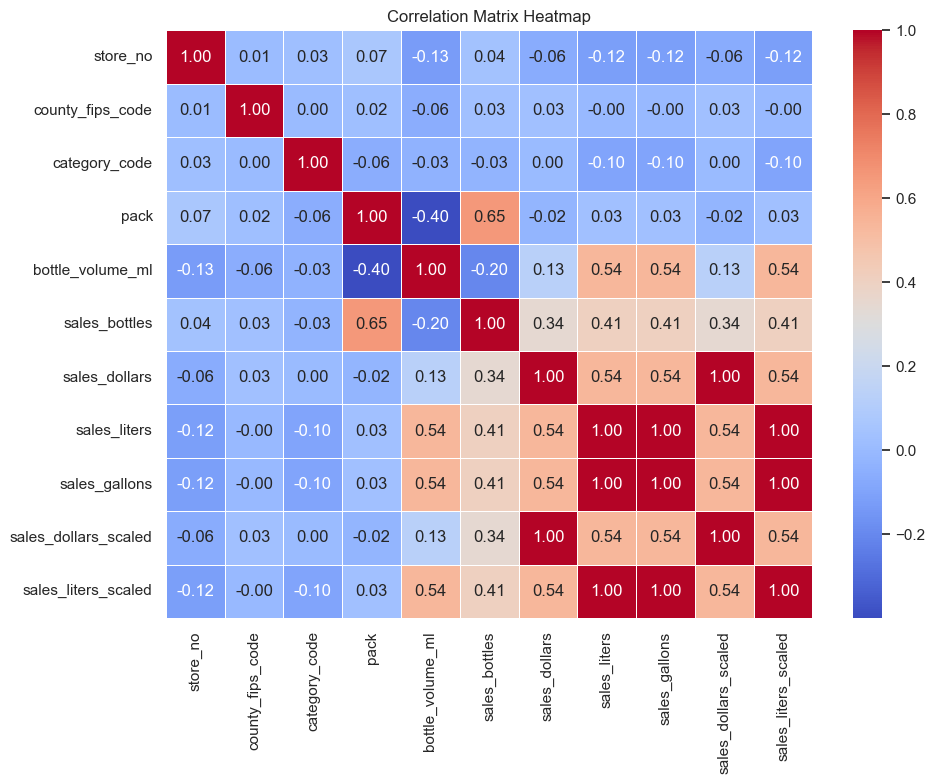

In [16]:
numeric_df = df_scaled.select_dtypes(include=[np.number])

# Compute the Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Display the raw correlation table
display(corr_matrix)

# Bonus: Plot a correlation heatmap for a visual representation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.savefig('Correlation_Matrix_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()